In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from tqdm import tqdm
import random

In [2]:
# Read in and event counts information
data_dir1 = '/home/kale-chen/Documents/PET/TPPT2026/data/hcircp.bin'
data_dir2 = '/home/kale-chen/Documents/PET/TPPT2026/data/hcircpgd.bin'
num_cols1 = 6
num_cols2 = 4
data_type = np.int16
idrange = 3072
num_rows1 = os.path.getsize(data_dir1) // (num_cols1 * data_type().itemsize)
num_rows2 = os.path.getsize(data_dir2) // (num_cols2 * data_type().itemsize)
data1 = np.memmap(data_dir1, dtype=data_type, mode='r', shape=(num_rows1, num_cols1))
data2 = np.memmap(data_dir2, dtype=data_type, mode='r', shape=(num_rows2, num_cols2))

# Event counts per channel for both data1 and data2
eventcounts1 = np.zeros(idrange * 2, dtype=np.int32)
eventcounts2 = np.zeros(idrange * 2, dtype=np.int32)

# For data1
for i in tqdm(range(0, num_rows1, 1000000), desc='Event counts data1'):
    chunk = data1[i:i+1000000]
    if num_cols1 == 6:
        ids = np.asarray(chunk[:, [1, 3]], dtype=np.int32)
    else:
        ids = np.asarray(chunk[:, [0, 1]], dtype=np.int32)
    ids[:, 0] = ids[:, 0] + idrange
    np.add.at(eventcounts1, ids, 1)

# For data2
for i in tqdm(range(0, num_rows2, 1000000), desc='Event counts data2'):
    chunk = data2[i:i+1000000]
    if num_cols2 == 6:
        ids = np.asarray(chunk[:, [1, 3]], dtype=np.int32)
    else:
        ids = np.asarray(chunk[:, [0, 1]], dtype=np.int32)
    ids[:, 0] = ids[:, 0] + idrange
    np.add.at(eventcounts2, ids, 1)

print(num_rows1, num_rows2)
print(data1[0:5])
print(data1[-6:-1])
print(data2[0:5])
print(data2[-6:-1])
print(np.sum(eventcounts1), np.sum(eventcounts2))

Event counts data2: 100%|██████████| 20/20 [00:01<00:00, 14.98it/s]

24592404 19704008
[[2341  333 2305 2796 -529    9]
 [2214  742 2570 2304  900    9]
 [2029  560 2319 2907 1359    9]
 [3042 1187 2888 1167 1737    9]
 [2547  575 2187 2265  811    9]]
[[ 2790   474  2076  2908    97   609]
 [ 2447   874  2157  2229 -5338   609]
 [ 2433   635  2536  2321  1025   609]
 [ 2533   482  2296  2925  4268   609]
 [ 2241   481  2803  2288 -5743   609]]
[[ 742 2304  900    0]
 [ 560 2907 1359    0]
 [ 575 2265  811    0]
 [ 404 2328 5641    0]
 [ 711 2331  138    0]]
[[  515  2339  -807   599]
 [  474  2908    97   599]
 [  635  2321  1025   599]
 [  482  2925  4268   599]
 [  481  2288 -5743   599]]
49184808 39408016


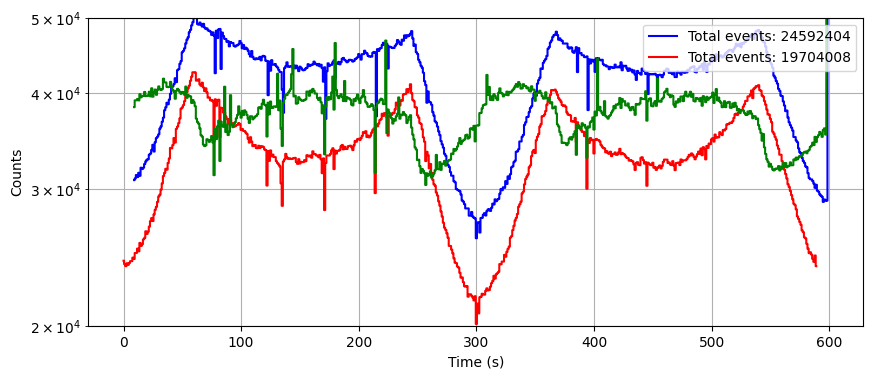

In [3]:
# Event counts per time bin
binwidth = 1
total_events1 = num_rows1
total_events2 = num_rows2
post_events1 = 0
post_events2 = 0

plt.figure(figsize=(10, 4))

heights1, edges1 = np.histogram(data1[:, num_cols1 - 1], bins = np.arange(data1[:, num_cols1 - 1].min(), data1[:, num_cols1 - 1].max() + binwidth, binwidth))
heights1, edges1 = heights1[9:], edges1[:-9]
plt.step(edges1[:-1], heights1, where='mid', color = 'blue', label = f'Total events: {total_events1}')
heights2, edges2 = np.histogram(data2[:, num_cols2 - 1], bins = np.arange(data2[:, num_cols2 - 1].min(), data2[:, num_cols2 - 1].max() + binwidth, binwidth))
heights2, edges2 = heights2[:-9], edges2[:-9]
plt.step(edges2[:-1], heights2, where='mid', color = 'red', label = f'Total events: {total_events2}')
plt.step(edges1[:-2], heights1[1:] / heights2[:] * 3e4, where = 'mid', color = 'green')
plt.yscale('log')
plt.ylim(2e4, 5e4)
plt.grid(which = 'both')
plt.legend(loc = 'upper right')
#plt.title(f'Run 3 (2mm) activity')
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.show()
